In [42]:
import os
import re
import h5py
import numpy as np
from collections import defaultdict
import spikeinterface.extractors as se

In [43]:
import sys
import os

# Add your script folder to Python's path
sys.path.append(r"C:\Users\sjs93\OneDrive\Documents\respiratory_pilot\src\file_conversion")

# Import your conversion function
import resp_to_h5_ecu_only as trodes

In [44]:
dir(trodes)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'convert_all_rec_to_h5',
 'convert_sessions',
 'h5py',
 'load_trodes_exports',
 'np',
 'os',
 'parse_fields',
 'read_trodes_dat_file',
 'write_h5']

In [45]:
session_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\1_1_RI2_f2_h_off_20260119_134817.rec"

In [55]:
analog, dio, time = trodes.load_trodes_exports(session_dir)

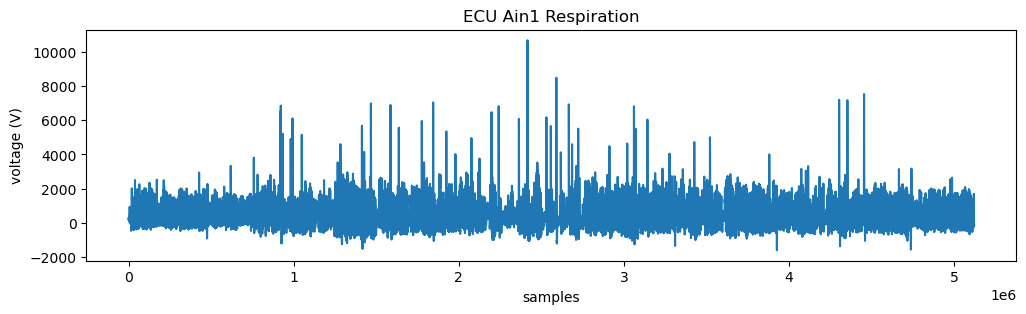

In [56]:
import matplotlib.pyplot as plt

analog_key = [k for k in analog if "Ain1" in k][0]
resp = analog[analog_key]["data"]["voltage"]

plt.figure(figsize=(12, 3))
plt.plot(resp)
plt.title("ECU Ain1 Respiration")
plt.xlabel("samples")
plt.ylabel("voltage (V)")
plt.show()

In [57]:
dio_key = [k for k in dio if "Din1" in k][0]
dio_data = dio[dio_key]["data"]

dio_data.dtype

dtype([('time', '<u4'), ('state', 'u1')])

In [50]:
times = dio_data["time"]
states = dio_data["state"]

on_times = times[states == 1]
off_times = times[states == 0]

In [58]:
out_h5 = r"D:\BLA_ChR_resp\h5\1_1_RI2_f2_h_off_20260119_134817.h5"
trodes.write_h5(out_h5, analog, dio, time)

In [59]:
import os

out_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\1_1_RI2_f2_h_off_20260119_134817.rec"
os.makedirs(out_dir, exist_ok=True)

out_h5 = os.path.join(
    out_dir,
    "1_1_RI1_f1_d_on_20260111_164638.h5"
)

trodes.write_h5(out_h5, analog, dio, time)

print("Exists:", os.path.exists(out_h5))

Exists: True


In [ ]:
data_root = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1"
output_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs"

trodes.convert_sessions(data_root, output_dir)


Processing: 1_1_RI2_f2_h_off_20260119_134817.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_1_RI2_f2_h_off_20260119_134817.h5

Processing: 1_2_RI2_f1_a_on_20260119_170144.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_2_RI2_f1_a_on_20260119_170144.h5

Processing: 1_3_RI2_f2_f_on_20260119_152733.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\1_3_RI2_f2_f_on_20260119_152733.h5

Processing: 2_1_RI2_f1_a_off_20260119_173923.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_1_RI2_f1_a_off_20260119_173923.h5

Processing: 2_2_RI2_f2_3_on_20260119_144717.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_2_RI2_f2_3_on_20260119_144717.h5

Processing: 2_3_RI2_f1_d_off_20260119_160619.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs\2_3_RI2_f1_d_off_20260119_160619.h5

Processing: 3_1_RI2_f2_f_off_20260119_164023.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs

In [ ]:
data_root = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2"
output_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs"

trodes.convert_sessions(data_root, output_dir)


Processing: 1_1_RI2_f1_d_on_20260120_141031.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\1_1_RI2_f1_d_on_20260120_141031.h5

Processing: 1_2_RI2_f2_e_off_20260120_161028.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\1_2_RI2_f2_e_off_20260120_161028.h5

Processing: 1_3_RI2_f1_b_off_20260120_120107.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\1_3_RI2_f1_b_off_20260120_120107.h5

Processing: 2_1_RI2_f2_g_on_20260120_163545.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\2_1_RI2_f2_g_on_20260120_163545.h5

Processing: 2_2_RI2_f1_c_off_20260120_130619.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\2_2_RI2_f1_c_off_20260120_130619.h5

Processing: 2_3_RI2_f2_h_on_20260120_144851.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\2_3_RI2_f2_h_on_20260120_144851.h5

Processing: 3_1_RI2_f1_b_on_20260120_135800.rec
  Wrote D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d2\h5_outputs\

In [ ]:
h5_dir = r"D:\BLA_ChR_resp\BLA_ChR_resp_RI2_hc_post_d1\h5_outputs"

h5_files = sorted([
    os.path.join(h5_dir, f)
    for f in os.listdir(h5_dir)
    if f.endswith(".h5")
])

len(h5_files), h5_files[:3]

(23,
 ['D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_1_RI2_f2_h_off_20260119_134817.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_2_RI2_f1_a_on_20260119_170144.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_3_RI2_f2_f_on_20260119_152733.h5'])

In [ ]:
import os

base_dir = r"D:\BLA_ChR_resp"

all_h5_files = []

for day in ["post_d1", "post_d2"]:
    
    h5_dir = fr"{base_dir}\BLA_ChR_resp_RI2_hc_{day}\h5_outputs"
    
    if os.path.exists(h5_dir):
        files = [
            os.path.join(h5_dir, f)
            for f in os.listdir(h5_dir)
            if f.endswith(".h5")
        ]
        
        all_h5_files.extend(files)

all_h5_files = sorted(all_h5_files)

len(all_h5_files), all_h5_files[:5]


(46,
 ['D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_1_RI2_f2_h_off_20260119_134817.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_2_RI2_f1_a_on_20260119_170144.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\1_3_RI2_f2_f_on_20260119_152733.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\2_1_RI2_f1_a_off_20260119_173923.h5',
  'D:\\BLA_ChR_resp\\BLA_ChR_resp_RI2_hc_post_d1\\h5_outputs\\2_2_RI2_f2_3_on_20260119_144717.h5'])

In [ ]:
import h5py

def load_ecu_h5(h5_path):
    with h5py.File(h5_path, "r") as f:
        analog = {k: f["analog"][k][()] for k in f["analog"].keys()}
        dio    = {k: f["dio"][k][()]    for k in f["dio"].keys()}
        time   = {k: f["time"][k][()]   for k in f["time"].keys()}
    return analog, dio, time

In [ ]:
all_sessions = {}

for h5_path in all_h5_files:
    
    day = "d1" if "post_d1" in h5_path else "d2"
    
    base = os.path.basename(h5_path).replace(".h5", "")
    session_name = f"{base}_{day}"
    
    analog, dio, time = load_ecu_h5(h5_path)

    all_sessions[session_name] = {
        "analog": analog,
        "dio": dio,
        "time": time
    }

print("Loaded sessions:", list(all_sessions.keys()))


Loaded sessions: ['1_1_RI2_f2_h_off_20260119_134817_d1', '1_2_RI2_f1_a_on_20260119_170144_d1', '1_3_RI2_f2_f_on_20260119_152733_d1', '2_1_RI2_f1_a_off_20260119_173923_d1', '2_2_RI2_f2_3_on_20260119_144717_d1', '2_3_RI2_f1_d_off_20260119_160619_d1', '3_1_RI2_f2_f_off_20260119_164023_d1', '3_2_RI2_f1_b_on_20260119_181446_d1', '3_3_RI2_f2_e_off_20260119_142053_d1', '4_2_RI2_f2_f_on_20260119_133333_d1', '4_3_RI2_f1_a_off_20260119_172948_d1', '5_1_RI2_m2_p_off_20260119_143035_d1', '5_2_RI2_m1_k_on_20260119_175411_d1', '5_3_RI2_m2_m_on_20260119_161502_d1', '6_2_RI2_m2_p_on_20260119_151011_d1', '6_3_RI2_m1_k_on_20260119_165027_d1', '7_1_RI2_m2_o_off_20260119_171203_d1', '7_2_RI2_m1_i_on_20260119_140337_d1', '7_3_RI2_m2_m_off_20260119_155215_d1', '8_1_RI2_m1_i_off_20260119_162623_d1', '8_2_RI2_m2_p_on_20260119_180514_d1', '8_3_RI2_m1_j_off_20260119_150003_d1', '9_1_RI2_m1_k_off_20260119_153823_d1', '1_1_RI2_f1_d_on_20260120_141031_d2', '1_2_RI2_f2_e_off_20260120_161028_d2', '1_3_RI2_f1_b_off_2

In [ ]:
for sess, data in all_sessions.items():
    print(sess)
    print("  Analog:", data["analog"].keys())
    print("  DIO:", data["dio"].keys())
    print("  Time:", data["time"].keys())

1_1_RI2_f2_h_off_20260119_134817_d1
  Analog: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.analog_ECU_Ain1', '1_1_RI2_f2_h_off_20260119_134817.timestamps'])
  DIO: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Din1', '1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Dout1'])
  Time: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.timestamps'])
1_2_RI2_f1_a_on_20260119_170144_d1
  Analog: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.analog_ECU_Ain1', '1_2_RI2_f1_a_on_20260119_170144.timestamps'])
  DIO: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.dio_ECU_Din1', '1_2_RI2_f1_a_on_20260119_170144.dio_ECU_Dout1'])
  Time: dict_keys(['1_2_RI2_f1_a_on_20260119_170144.timestamps'])
1_3_RI2_f2_f_on_20260119_152733_d1
  Analog: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.analog_ECU_Ain1', '1_3_RI2_f2_f_on_20260119_152733.timestamps'])
  DIO: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.dio_ECU_Din1', '1_3_RI2_f2_f_on_20260119_152733.dio_ECU_Dout1'])
  Time: dict_keys(['1_3_RI2_f2_f_on_20260119_152733.

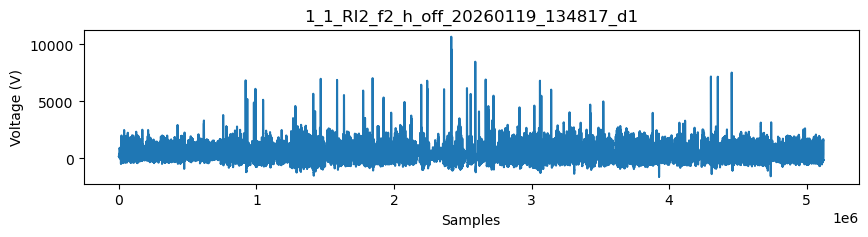

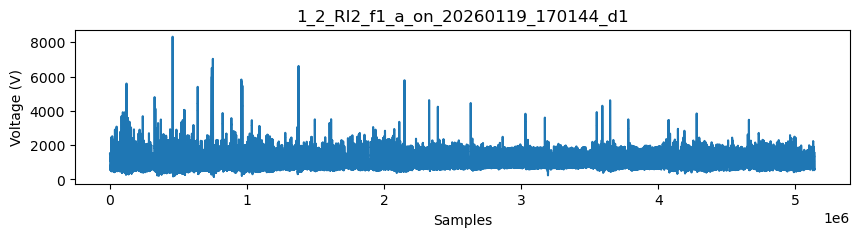

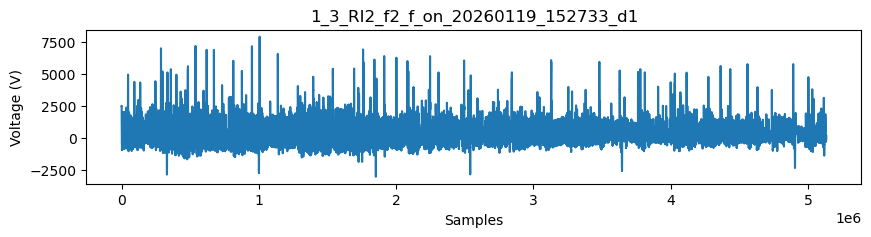

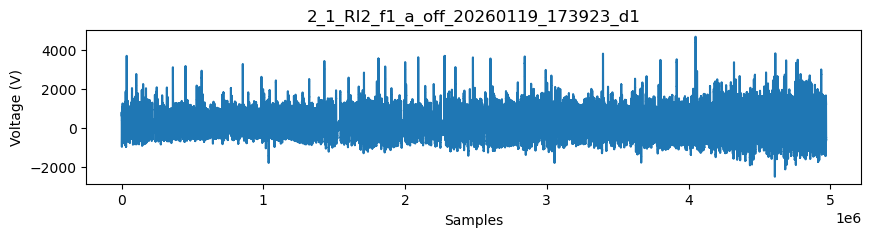

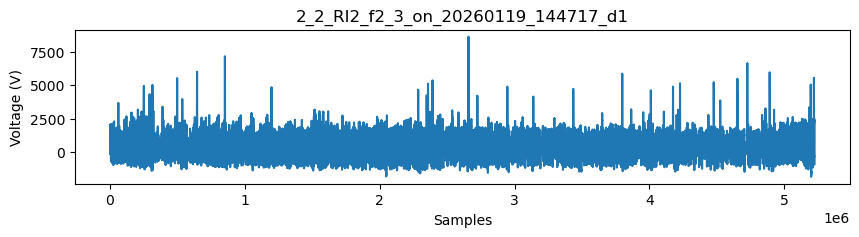

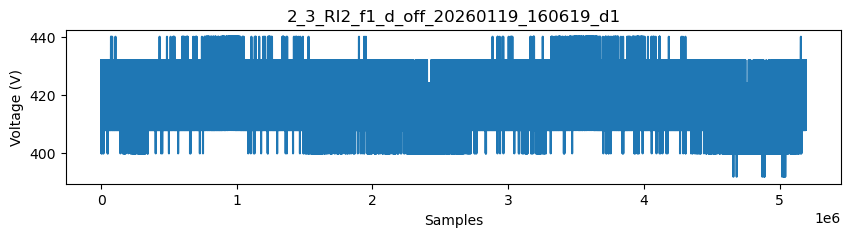

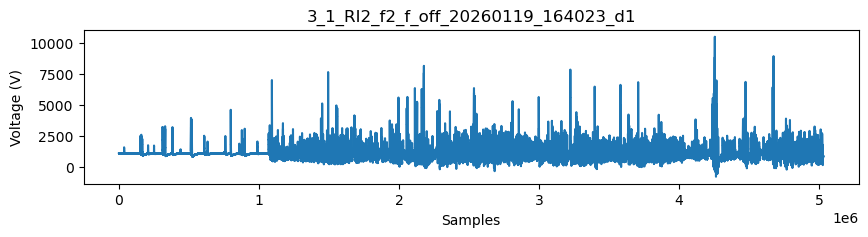

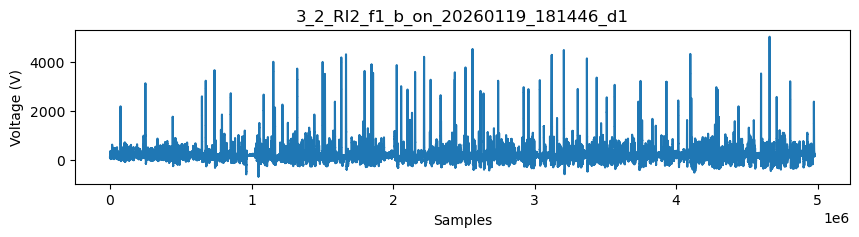

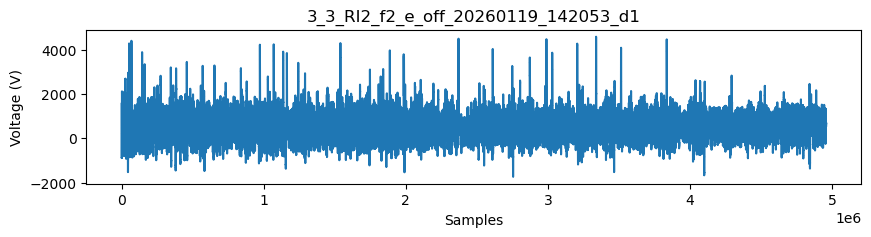

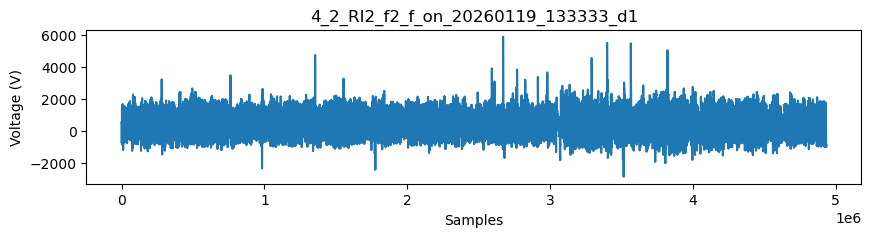

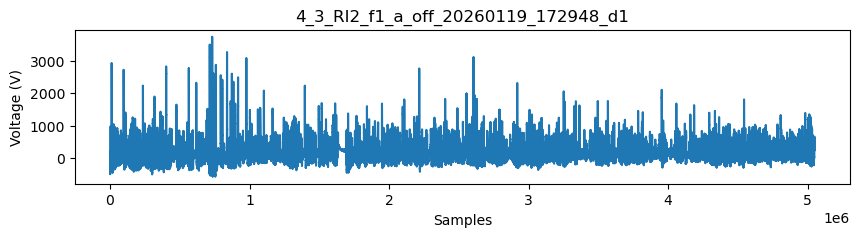

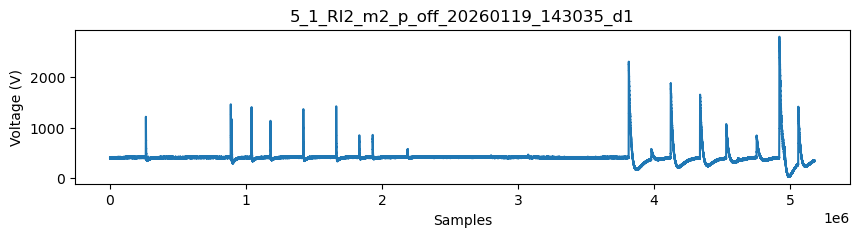

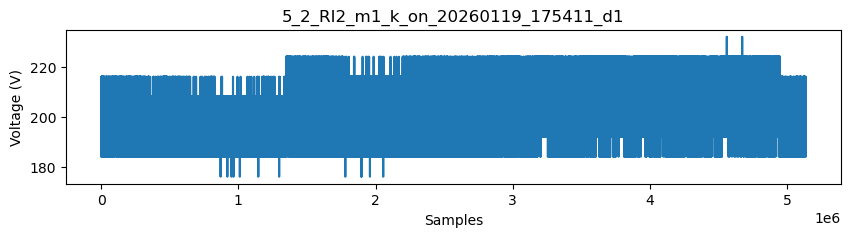

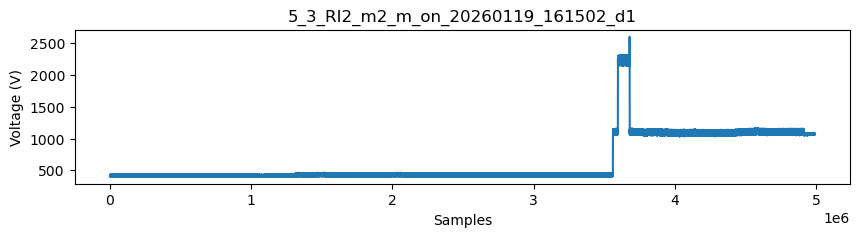

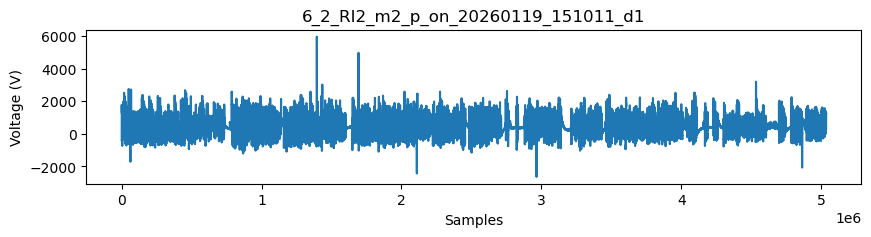

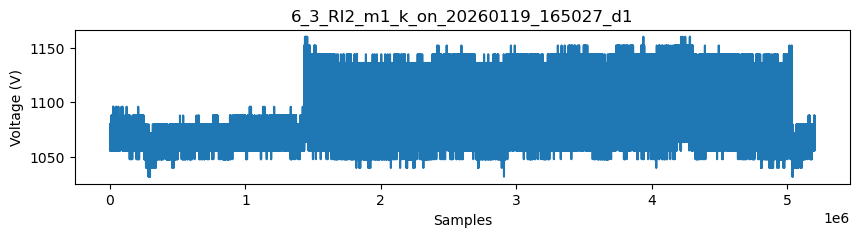

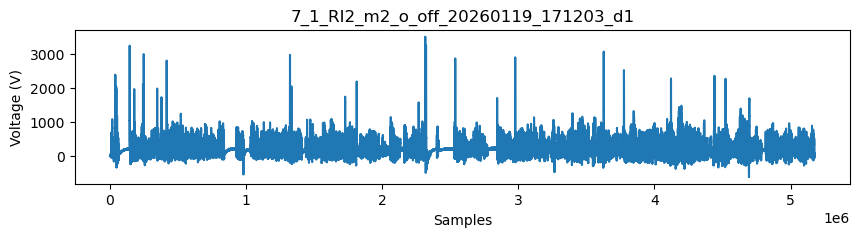

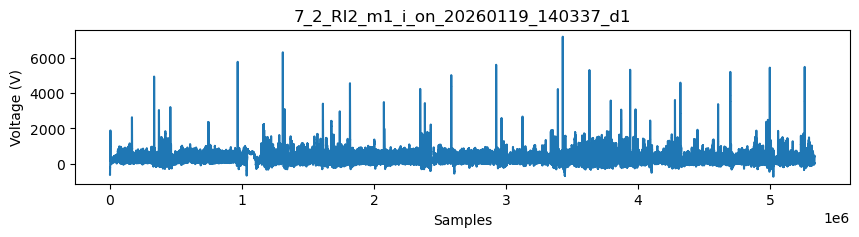

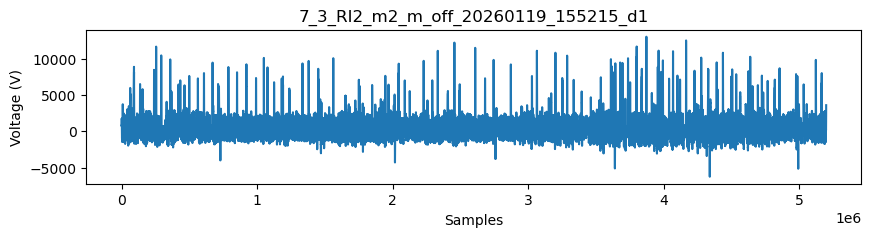

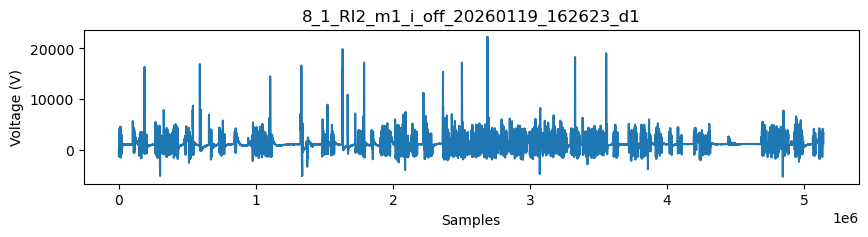

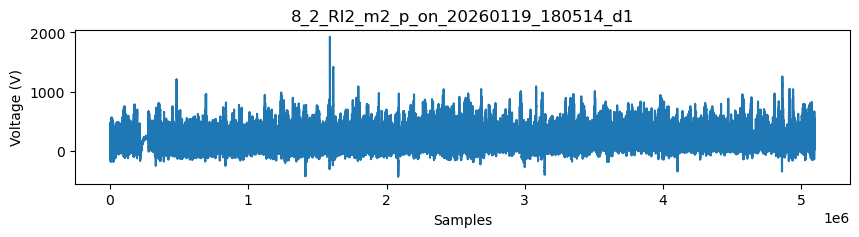

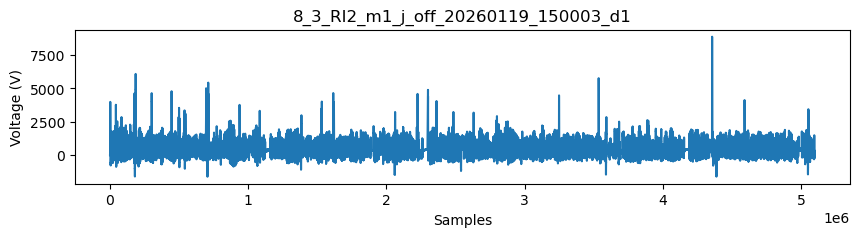

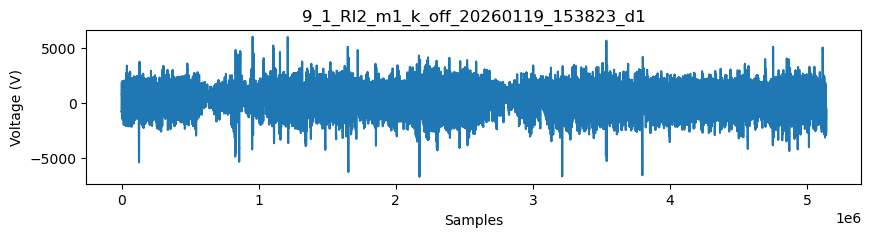

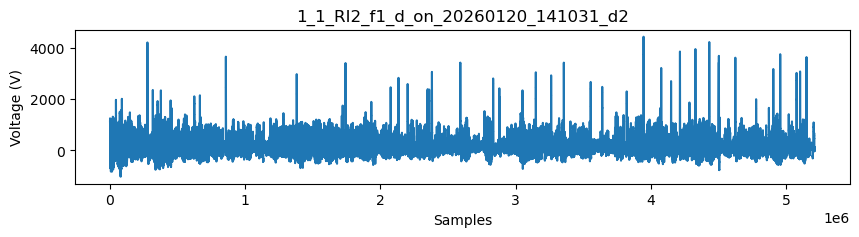

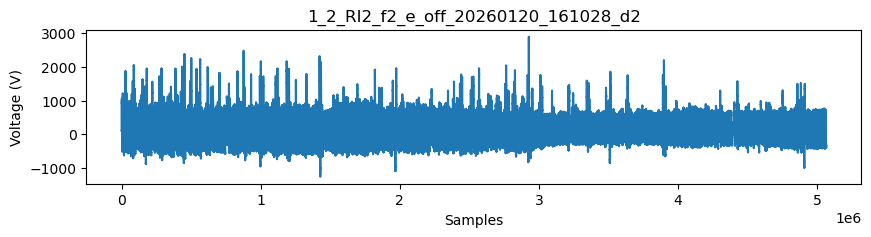

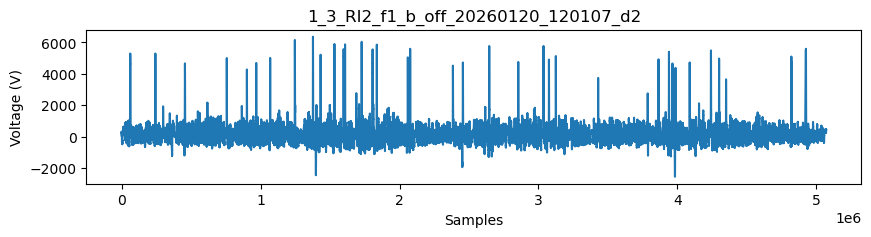

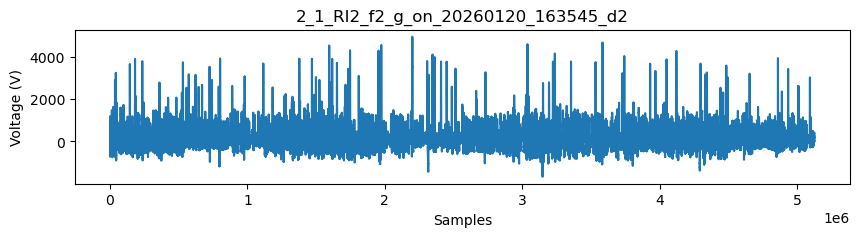

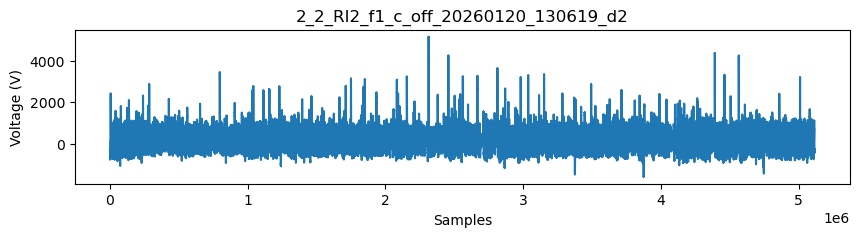

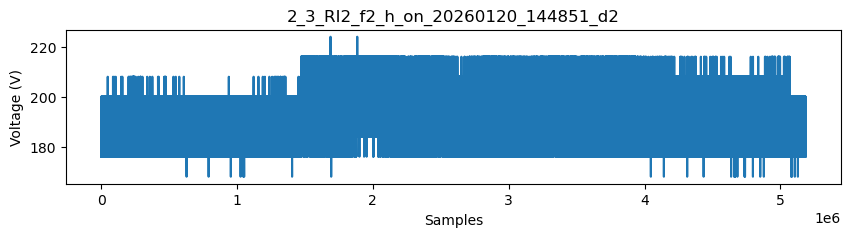

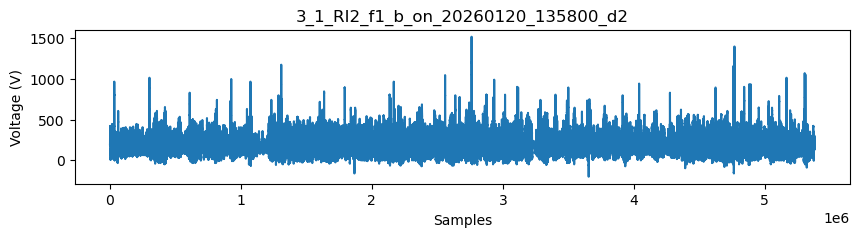

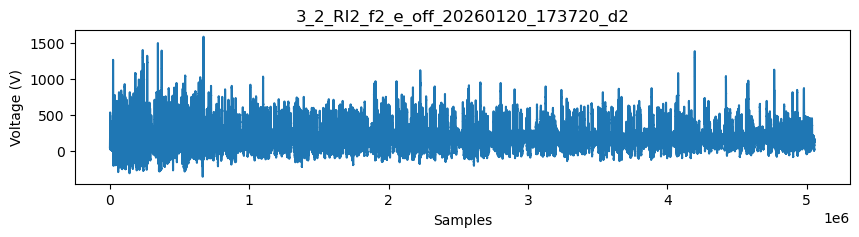

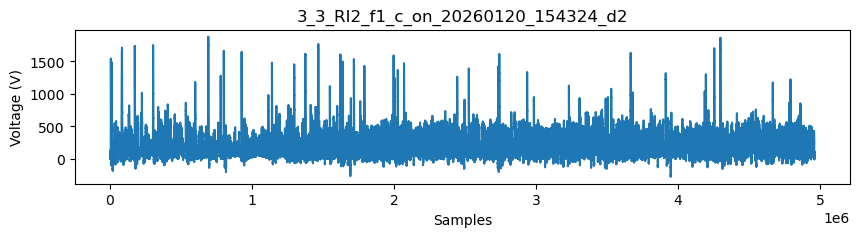

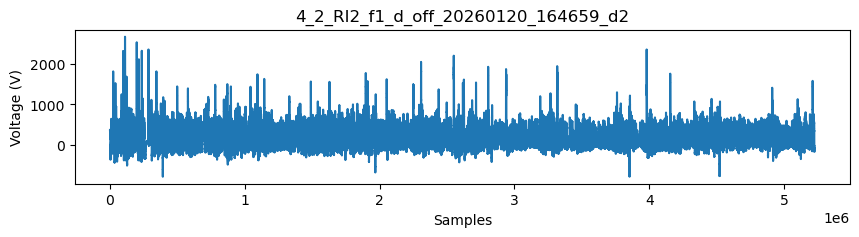

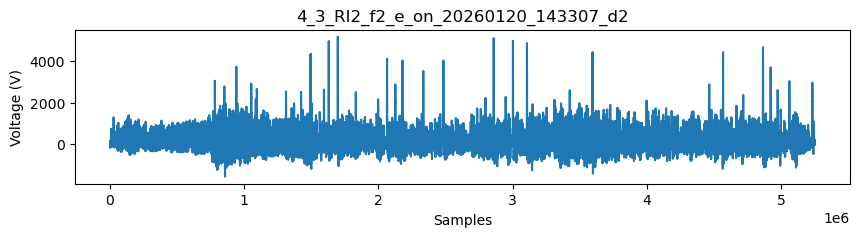

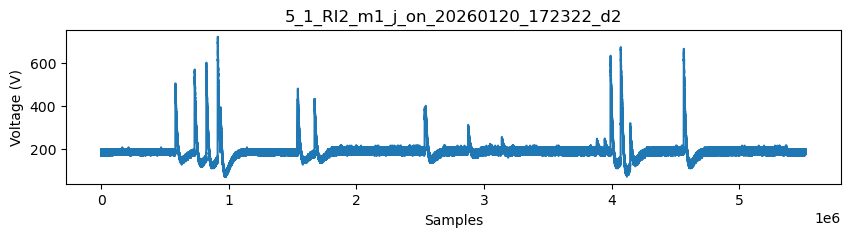

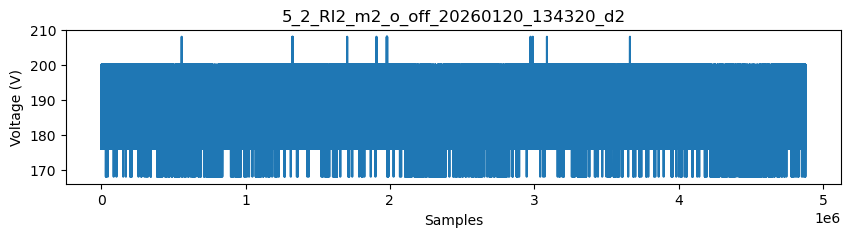

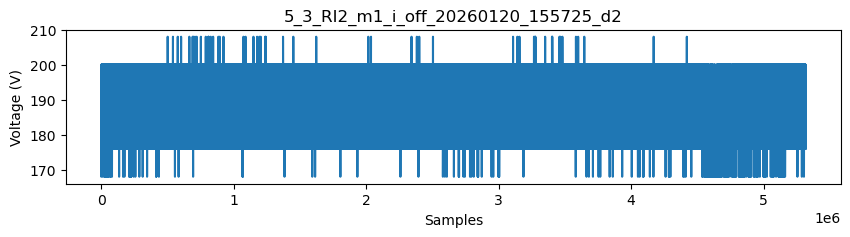

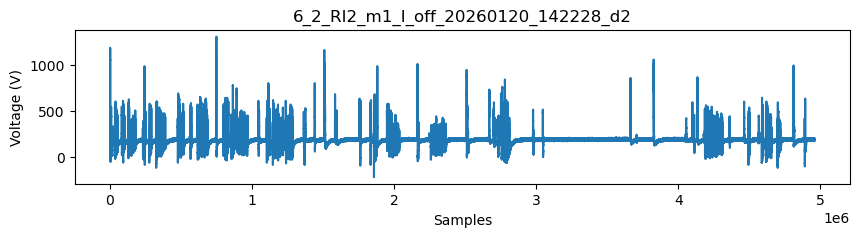

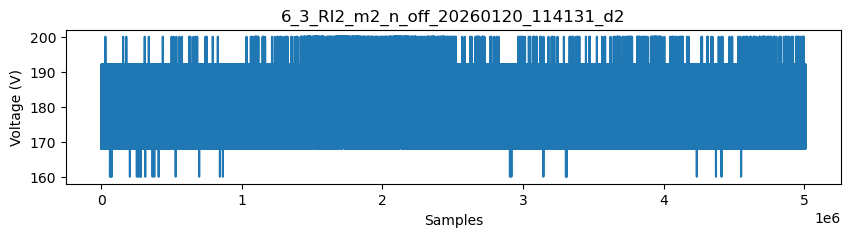

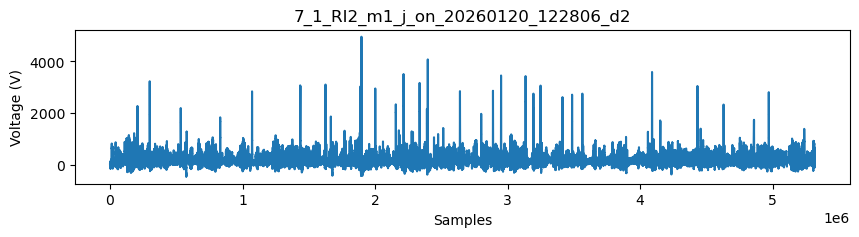

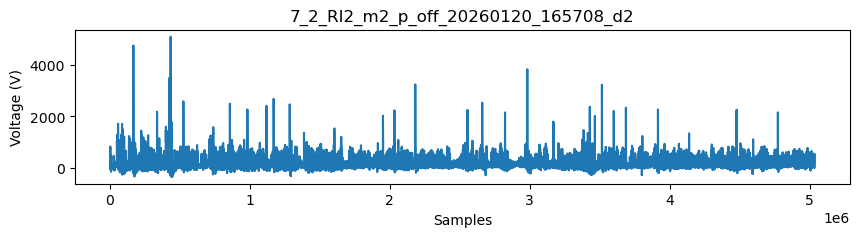

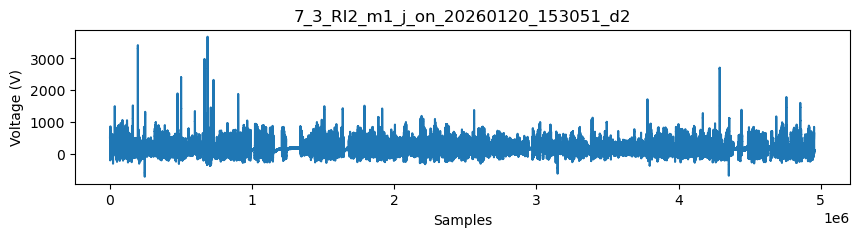

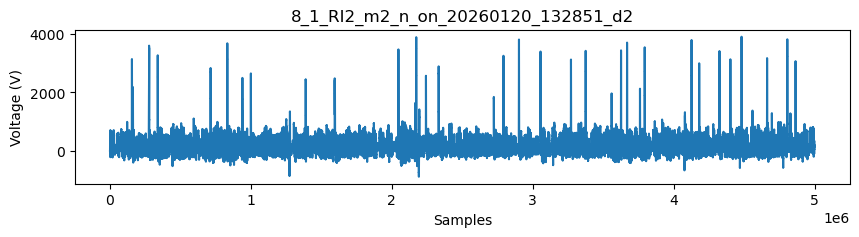

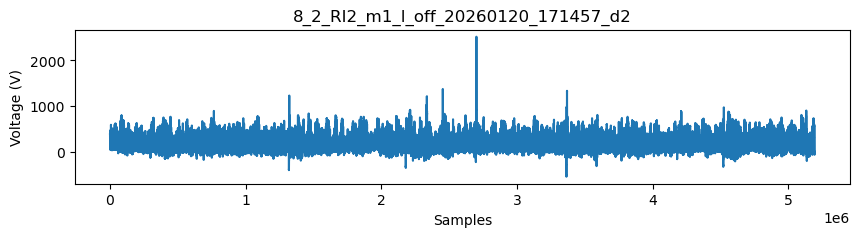

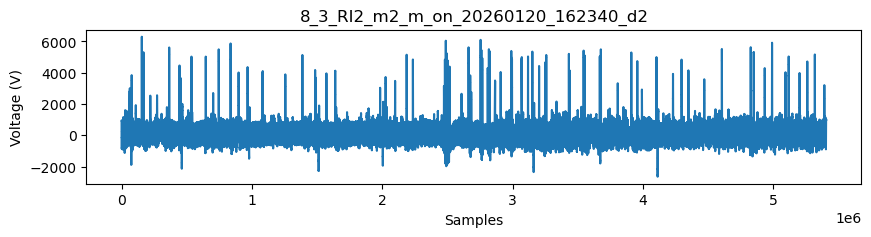

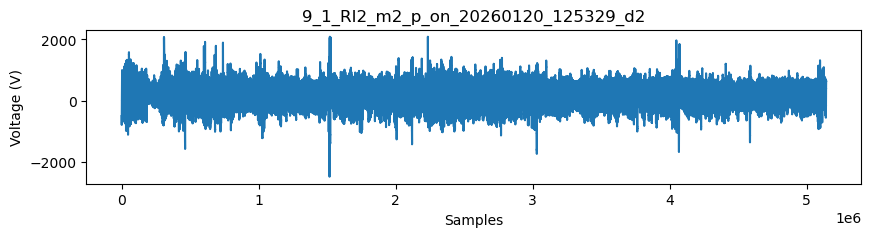

In [ ]:
import matplotlib.pyplot as plt

for sess, data in all_sessions.items():
    analog = data["analog"]
    key = [k for k in analog if "Ain1" in k][0]
    resp = analog[key]["voltage"]

    plt.figure(figsize=(10, 2))
    plt.plot(resp)
    plt.title(sess)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Samples")
    plt.show()

In [ ]:
session_name = list(all_sessions.keys())[0]
session = all_sessions[session_name]

print("Analog keys:", session["analog"].keys())
print("DIO keys:", session["dio"].keys())
print("Time keys:", session["time"].keys())


Analog keys: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.analog_ECU_Ain1', '1_1_RI2_f2_h_off_20260119_134817.timestamps'])
DIO keys: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Din1', '1_1_RI2_f2_h_off_20260119_134817.dio_ECU_Dout1'])
Time keys: dict_keys(['1_1_RI2_f2_h_off_20260119_134817.timestamps'])


In [ ]:
def qc_respiration(session_name, all_sessions):
    
    session = all_sessions[session_name]
    
    # --- Find respiration channel ---
    analog_keys = list(session["analog"].keys())
    resp_key = [k for k in analog_keys if "analog_ECU_Ain" in k][0]
    
    # --- Find timestamp channel ---
    time_keys = list(session["time"].keys())
    time_key = [k for k in time_keys if "timestamps" in k][0]
    
    # --- Extract data properly ---
    resp = session["analog"][resp_key]["voltage"]
    time = session["time"][time_key]
    
    print(f"\nQC for: {session_name}")
    print("Length:", len(resp))
    print("Mean:", np.mean(resp))
    print("Std:", np.std(resp))
    print("Min:", np.min(resp))
    print("Max:", np.max(resp))
    
    dt = np.diff(time)
    fs = 1 / np.mean(dt)
    print("Estimated Fs:", round(fs, 2), "Hz")
    
    # Plot first 10 sec
    seconds = 10
    n = int(fs * seconds)
    
    plt.figure(figsize=(10,4))
    plt.plot(time[:n], resp[:n])
    plt.xlabel("Time (s)")
    plt.ylabel("Resp voltage")
    plt.title(f"{session_name} – First 10 sec")
    plt.show()


In [ ]:
resp_raw = session["analog"][resp_key]
print(resp_raw.dtype)


NameError: name 'resp_key' is not defined